# TSViT para segmentación temporal de cultivos: el aporte de la fenología

Este notebook documenta el entrenamiento de **TSViT** (*Temporo-Spatial Vision
Transformer*, Tarasiou et al. 2023), una arquitectura que segmenta cultivos
pixel por pixel consumiendo la **serie temporal completa** de imágenes
Sentinel-2, no una sola fecha.

Lo que distingue a TSViT de una CNN 2D clásica es cómo organiza la atención.
Primero aplica un **encoder temporal** sobre la secuencia de `T` fechas de
adquisición de cada parche, invirtiendo el orden habitual de un video-ViT
(que mira primero el espacio); recién después aplica el **encoder espacial**.
Usa **K cls tokens** (uno por clase de cultivo) para que cada clase tenga su
propio canal de predicción, y un **positional encoding temporal indexado por la
fecha real de adquisición** (el día del año, DOY). Esto último es crítico:
Sentinel-2 tiene revisitas irregulares porque las nubes obligan a descartar
fechas, así que el modelo necesita saber *cuándo* se tomó cada imagen, no solo
su posición en la secuencia.

Comparamos dos variantes de la misma arquitectura:

- **Variante base (`tsvit`)**: solo el transformer factorizado temporal-espacial.
- **Variante con fenología (`tsvit-pheno`)**: la misma red más una rama
  semántica que alinea por contraste las features visuales de cada pixel con
  descripciones fenológicas por clase generadas por un LLM (método de Wen et
  al. 2025, *Phenology Description is All You Need!*). Su Tabla 2 muestra que
  describir la fenología casi **duplica el F1** en escenario zero-shot.

El notebook compara ambas variantes y muestra el **delta** lado a lado: cuánto
aporta la fenología. **No entrena en línea por defecto**: reutiliza los
checkpoints de las dos corridas completas (30 epochs) ya entrenadas en GPU y los
evalúa sobre el fold de validación, de modo que las métricas son consistentes en
todas las secciones. El entrenamiento desde cero por la interfaz de línea de
comandos (con registro en MLflow de `code_version` / `data_version`) queda como
ruta opcional en modo completo (`run_full=True`, p. ej. `-p run_full True`).

## Requisitos para ejecución end-to-end

- `data/PASTIS-R/` descomprimido (parches Sentinel-2 + máscaras por pixel).
- Dependencias instaladas via `poetry install --with ml`.
- GPU recomendada para el entrenamiento real; en CPU el modo rápido sigue
  siendo ejecutable.

Si el dataset o los checkpoints no están disponibles, el notebook continúa en
modo degradado: muestra el comando que se habría ejecutado y un mensaje claro,
sin romper la ejecución.


In [1]:
# Parameters cell (papermill). The default is LOW on purpose so the end-to-end
# run is fast; real training is launched with, for example,
# `-p run_full True -p epochs 30`.
epochs = 2
batch_size = 4
n_timesteps = 10
target = "semantic18"
device = "auto"
run_full = False
figures_dir = "paper/figures/us-025"
checkpoint_dir = "checkpoints/segmentation"
eval_max_patches = None  # None = full val fold; int for smoke

In [2]:
# Parameters
device = "cuda"


In [3]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display

# Bootstrap repo root: locate pyproject.toml by walking up from the CWD so the
# notebook works from notebooks/models/ without assuming the folder name.
_REPO_BOOTSTRAP = Path.cwd().resolve()
for _candidate in (_REPO_BOOTSTRAP, *_REPO_BOOTSTRAP.parents):
    if (_candidate / "pyproject.toml").is_file():
        _REPO_BOOTSTRAP = _candidate
        break
if str(_REPO_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(_REPO_BOOTSTRAP))

from ml.utils.notebook_setup import find_repo_root
from ml.utils.mlflow_utils import resolve_tracking_uri

# Polars: rich HTML rendering in Jupyter.
pl.Config.set_tbl_formatting("ASCII_MARKDOWN")
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200

%load_ext autoreload
%autoreload 2

REPO = find_repo_root()
FIGURES = REPO / figures_dir
FIGURES.mkdir(parents=True, exist_ok=True)

# MLflow run names per variant (must match the ones in the training CLI so the
# runs can be retrieved later).
RUN_NAMES = {
    "tsvit": "alt-tsvit-v1",
    "tsvit-pheno": "alt-tsvit-pheno-v1",
}

display(Markdown(
    f"**Configuracion** — variantes: `tsvit`, `tsvit-pheno` · "
    f"epochs: `{epochs}` · n_timesteps: `{n_timesteps}` · target: `{target}` · "
    f"modo: `{'completo' if run_full else 'rapido'}`"
))

**Configuracion** — variantes: `tsvit`, `tsvit-pheno` · epochs: `2` · n_timesteps: `10` · target: `semantic18` · modo: `rapido`

## Seccion 1 — La arquitectura TSViT

TSViT segmenta sobre **PASTIS-R**, un benchmark donde cada muestra es un parche
Sentinel-2 observado varias veces a lo largo del año, con una máscara que
etiqueta cada pixel con su tipo de cultivo. El modelo recibe la serie temporal
completa del parche (los `n_timesteps` pasos) y produce una clase por pixel.

La clave del diseño es el orden de los dos encoders y cómo tratan el tiempo:

- **Encoder temporal primero**: a diferencia de un video-ViT, que razona
  primero sobre el espacio y luego sobre el tiempo, TSViT invierte el orden.
  Cada posición espacial se procesa primero como una secuencia temporal, de
  modo que el modelo aprende la *trayectoria* de cada pixel a lo largo de la
  temporada antes de mirar a sus vecinos.
- **Encoder espacial después**: una vez resumida la dinámica temporal, una
  segunda etapa de atención integra el contexto espacial dentro del parche
  (bordes de parcela, vecindad, textura).
- **K cls tokens**: la arquitectura introduce un token de clase por cada una de
  las `K` clases de cultivo. Cada token agrega evidencia para su clase, lo que
  da a la red un canal dedicado por cultivo en lugar de un único vector
  compartido.
- **Positional encoding temporal por DOY real**: el encoding posicional del eje
  temporal no usa el índice de la secuencia (1, 2, 3, ...) sino el **día del
  año** real de cada adquisición. Esto es crítico porque Sentinel-2 sufre
  revisitas irregulares: las nubes obligan a descartar fechas, así que la
  separación entre dos observaciones consecutivas no es uniforme. Indexar por
  DOY le dice al modelo qué tan lejos en el calendario están dos imágenes.

Las dos variantes comparten exactamente este núcleo; solo difieren en si se
agrega la rama fenológica contrastiva (Seccion 3).

In [4]:
def _train_via_cli(model_kind: str, n_epochs: int) -> dict[str, float | str | None]:
    """Launch the training CLI for a TSViT variant (only when ``run_full``).

    Invokes ``python -m ml.train.train_segmentation`` via subprocess so the run
    is logged to MLflow with its ``code_version`` / ``data_version`` tags. Used
    only in full mode: the default path of the notebook reuses the already
    trained checkpoints (see ``evaluate_variant``). The subprocess forces
    ``PYTHONIOENCODING=utf-8`` so MLflow's run-URL emoji does not crash the
    child on a cp1252 Windows console.

    Args:
        model_kind: 'tsvit' or 'tsvit-pheno'.
        n_epochs: Number of epochs to train.

    Returns:
        Dictionary with `model`, `miou`, `f1_macro`, `pixel_acc`, `returncode`
        and `error`. Metrics are `None` if the run failed or could not be parsed.
    """
    import os

    cmd = [
        sys.executable, "-m", "ml.train.train_segmentation",
        "--model", model_kind,
        "--epochs", str(n_epochs),
        "--batch-size", str(batch_size),
        "--n-timesteps", str(n_timesteps),
        "--target", target,
        "--device", device,
        "--run-name", RUN_NAMES.get(model_kind, model_kind),
    ]
    display(Markdown(f"`{' '.join(cmd)}`"))

    result: dict[str, float | str | None] = {
        "model": model_kind, "miou": None, "f1_macro": None,
        "pixel_acc": None, "returncode": None, "error": None,
    }
    # Force UTF-8 on the child stdout/stderr: MLflow 3.x prints a runner emoji
    # when closing the run, and the default Windows cp1252 console raises
    # UnicodeEncodeError on it.
    child_env = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"}
    try:
        proc = subprocess.run(
            cmd, cwd=str(REPO), capture_output=True, text=True, check=False,
            encoding="utf-8", errors="replace", env=child_env,
        )
    except OSError as exc:
        result["error"] = f"No se pudo lanzar el subprocess: {exc}"
        print(f"  {model_kind}: subprocess no disponible ({exc})")
        return result

    result["returncode"] = proc.returncode
    log = (proc.stdout or "") + "\n" + (proc.stderr or "")
    if proc.returncode != 0:
        tail = "\n".join(log.strip().splitlines()[-12:])
        result["error"] = f"returncode={proc.returncode}"
        print(f"  {model_kind}: entrenamiento fallido (returncode={proc.returncode})")
        if tail:
            display(Markdown(f"```\n{tail}\n```"))
        return result

    # The CLI logs `cli_done` (structlog key=value) with the best-epoch metrics.
    for line in reversed(log.splitlines()):
        if "cli_done" in line:
            for key in ("miou", "f1_macro", "pixel_acc"):
                token = f"{key}="
                if token in line:
                    raw = line.split(token, 1)[1].split()[0].rstrip(",")
                    try:
                        result[key] = float(raw)
                    except ValueError:
                        result[key] = None
            break
    miou = result["miou"]
    print(f"  {model_kind}: mIoU={miou:.4f}" if isinstance(miou, float)
          else f"  {model_kind}: corrida OK pero no se parsearon metricas del log")
    return result


def evaluate_variant(model_kind: str) -> dict[str, float | str | None]:
    """Return the validation metrics of an already-trained TSViT variant.

    This is the **default** path of the notebook. Instead of re-training a smoke
    model online (slow, and noisy on a shared box), it reads the metrics of the
    real 30-epoch checkpoint that lives under ``checkpoint_dir``: it loads the
    ``best.pt`` and evaluates it over the full validation fold with the same
    ``evaluate_checkpoint`` used in Section 5, so the bar chart and the delta of
    Section 4 match the per-class analysis below exactly. If the checkpoint or
    the dataset is missing, it falls back to degraded mode (metrics ``None``).

    Args:
        model_kind: 'tsvit' or 'tsvit-pheno'.

    Returns:
        Dictionary with `model`, `miou`, `f1_macro`, `pixel_acc`, `returncode`
        and `error`. ``returncode`` is 0 when the checkpoint could be evaluated.
    """
    ckpt_name = "tsvit-v1" if model_kind == "tsvit" else "tsvit-pheno-v1"
    ckpt_path = REPO / checkpoint_dir / ckpt_name / "best.pt"
    result: dict[str, float | str | None] = {
        "model": model_kind, "miou": None, "f1_macro": None,
        "pixel_acc": None, "returncode": None, "error": None,
    }
    display(Markdown(
        f"Evaluando checkpoint entrenado (30 epochs) "
        f"`{ckpt_path.relative_to(REPO)}` sobre el fold de validacion."
    ))
    if not ckpt_path.is_file():
        result["error"] = "checkpoint ausente"
        print(f"  {model_kind}: checkpoint ausente ({ckpt_path.relative_to(REPO)}); modo degradado")
        return result

    from ml.data.pastis_seg_dataset import PASTISSegmentationDataset
    from ml.eval.segmentation_inference import evaluate_checkpoint, load_segmentation_model

    n_classes = 18 if target == "semantic18" else 6
    try:
        ds = PASTISSegmentationDataset(
            folds=(4,), n_timesteps=n_timesteps, collapse_time=None, target=target
        )
        model = load_segmentation_model(
            ckpt_path, model_kind=model_kind, num_classes=n_classes,
            n_timesteps=n_timesteps, device=device,
        )
        metrics, _ = evaluate_checkpoint(
            model, ds, model_kind=model_kind, num_classes=n_classes,
            max_patches=eval_max_patches,
        )
        del model
    except Exception as exc:  # noqa: BLE001 - degraded mode in the notebook
        result["error"] = str(exc)
        print(f"  {model_kind}: evaluacion fallida ({exc}); modo degradado")
        return result

    result.update({
        "miou": float(metrics["miou"]),
        "f1_macro": float(metrics["f1_macro"]),
        "pixel_acc": float(metrics["pixel_acc"]),
        "returncode": 0,
    })
    print(f"  {model_kind}: mIoU={result['miou']:.4f}")
    return result


def run_training(model_kind: str, n_epochs: int) -> dict[str, float | str | None]:
    """Produce the metrics of a TSViT variant for the comparison sections.

    Default (``run_full=False``): reuse the already-trained 30-epoch checkpoint
    via :func:`evaluate_variant`, so the notebook is fast and reproducible and
    its numbers are consistent across all sections. Full mode (``run_full=True``)
    instead re-trains from scratch through the CLI (:func:`_train_via_cli`) and
    logs a fresh MLflow run; raise the epochs via papermill (``-p epochs 30``).
    """
    if run_full:
        return _train_via_cli(model_kind, n_epochs)
    return evaluate_variant(model_kind)


## Seccion 2 — Variante base (sin fenologia)

La primera variante es TSViT en su forma pura: solo el transformer factorizado
temporal-espacial descrito arriba, sin ninguna ayuda semántica externa. Aprende
a separar cultivos únicamente a partir de la evolución espectral de cada pixel a
lo largo de la temporada y del contexto espacial del parche. Esta variante es la
**línea base** contra la que mediremos el aporte de la fenología.

Por defecto evaluamos el checkpoint de su corrida completa (30 epochs), ya
entrenada y registrada en el experimento `agrosat-segmentation` como
`alt-tsvit-v1` con los tags `code_version` (SHA git) y `data_version` (hash DVC
del dataset). En modo completo (`run_full=True`) se re-entrena desde cero por la
interfaz de línea de comandos.


In [5]:
# Base variant: TSViT without phenology. Default path evaluates the trained
# 30-epoch checkpoint; full mode (run_full) re-trains with the `epochs` from the
# parameters cell (raise it via papermill, e.g. `-p run_full True -p epochs 30`).
n_epochs = epochs

display(Markdown("### `tsvit` (base)"))
result_base = run_training("tsvit", n_epochs)

base_df = pl.DataFrame(
    [result_base],
    schema={
        "model": pl.Utf8,
        "miou": pl.Float64,
        "f1_macro": pl.Float64,
        "pixel_acc": pl.Float64,
        "returncode": pl.Int64,
        "error": pl.Utf8,
    },
)
display(base_df.select("model", "miou", "f1_macro", "pixel_acc", "returncode"))

### `tsvit` (base)

Evaluando checkpoint entrenado (30 epochs) `checkpoints\segmentation\tsvit-v1\best.pt` sobre el fold de validacion.

2026-06-15 11:48:58 [info     ] pastis_seg_dataset_init        collapse_time=None folds=(4,) has_norm_stats=True n_patches=482 num_classes=18 target=semantic18


2026-06-15 11:49:01 [info     ] segmentation_model_loaded      best_epoch=27.0 checkpoint=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\checkpoints\segmentation\tsvit-v1\best.pt device=cuda model_kind=tsvit num_classes=18


2026-06-15 11:50:52 [info     ] checkpoint_evaluated           f1_macro=0.7473 miou=0.6215 model_kind=tsvit n_patches=482 num_classes=18 pixel_acc=0.8724


  tsvit: mIoU=0.6215


model,miou,f1_macro,pixel_acc,returncode
str,f64,f64,f64,i64
"""tsvit""",0.621468,0.747299,0.872364,0


## Sección 3 — Variante con fenología contrastiva

La segunda variante agrega a TSViT la **rama fenológica-contrastiva** propuesta
por Wen et al. (2025). La idea es enseñarle al encoder visual *que patrón
temporal corresponde a cada cultivo* usando texto como guía.

El procedimiento tiene tres pasos:

1. **Descripción fenológica por clase**: para cada cultivo se resume su curva
   NDVI media a lo largo de la temporada (cuando germina, cuando alcanza su
   máximo de verdor, cuando se cosecha) y se entrega esa descripción a un LLM,
   que genera un texto fenológico de la clase.
2. **Embedding del texto**: ese texto se convierte en un vector (prototipo
   semántico de la clase).
3. **Alineamiento por contraste (InfoNCE)**: durante el entrenamiento, las
   features visuales de cada pixel se acercan al prototipo de su clase y se
   alejan de los prototipos de las demás clases. Así el texto fenológico actúa
   como ancla: empuja las features de cada pixel hacia el cluster semántico de
   su cultivo.

El núcleo TSViT es idéntico al de la Sección 2; lo único que cambia es este
término contrastivo adicional. Su corrida completa se registra como
`alt-tsvit-pheno-v1`.


In [6]:
display(Markdown("### `tsvit-pheno` (con fenologia)"))
result_pheno = run_training("tsvit-pheno", n_epochs)

pheno_df = pl.DataFrame(
    [result_pheno],
    schema={
        "model": pl.Utf8,
        "miou": pl.Float64,
        "f1_macro": pl.Float64,
        "pixel_acc": pl.Float64,
        "returncode": pl.Int64,
        "error": pl.Utf8,
    },
)
display(pheno_df.select("model", "miou", "f1_macro", "pixel_acc", "returncode"))

### `tsvit-pheno` (con fenologia)

Evaluando checkpoint entrenado (30 epochs) `checkpoints\segmentation\tsvit-pheno-v1\best.pt` sobre el fold de validacion.

2026-06-15 11:50:54 [info     ] pastis_seg_dataset_init        collapse_time=None folds=(4,) has_norm_stats=True n_patches=482 num_classes=18 target=semantic18


2026-06-15 11:50:54 [info     ] segmentation_model_loaded      best_epoch=28.0 checkpoint=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\checkpoints\segmentation\tsvit-pheno-v1\best.pt device=cuda model_kind=tsvit-pheno num_classes=18


2026-06-15 11:52:27 [info     ] checkpoint_evaluated           f1_macro=0.75 miou=0.6253 model_kind=tsvit-pheno n_patches=482 num_classes=18 pixel_acc=0.8759


  tsvit-pheno: mIoU=0.6253


model,miou,f1_macro,pixel_acc,returncode
str,f64,f64,f64,i64
"""tsvit-pheno""",0.625312,0.750039,0.875908,0


## Seccion 4 — Comparativa: el aporte de la fenología

Con ambas corridas listas, ponemos las dos variantes lado a lado y calculamos
el **delta** de cada métrica (`tsvit-pheno` menos `tsvit`). Un delta positivo
significa que describir la fenología ayudó a segmentar mejor.

Wen et al. (2025) reportan que el alineamiento fenológico casi duplica el F1 en
el escenario zero-shot (su Tabla 2). Aquí no estamos en zero-shot, así que la
mejora esperada es más moderada, pero la dirección debería ser la misma.

In [7]:
# Combine the two variants and compute the delta of each metric.
results_df = pl.concat([base_df, pheno_df])
by_model = {row["model"]: row for row in results_df.iter_rows(named=True)}
base = by_model.get("tsvit")
pheno = by_model.get("tsvit-pheno")

delta_df: pl.DataFrame | None = None
if base is None or pheno is None:
    display(Markdown(
        "> Se necesitan ambas corridas `tsvit` y `tsvit-pheno`. Modo degradado."
    ))
elif base["miou"] is None or pheno["miou"] is None:
    display(Markdown(
        "> Una de las corridas (`tsvit` / `tsvit-pheno`) no produjo metricas; "
        "no se puede calcular el delta. Modo degradado."
    ))
else:
    delta_rows = []
    for metric in ("miou", "f1_macro", "pixel_acc"):
        b = float(base[metric])
        p = float(pheno[metric])
        delta_rows.append({
            "metrica": metric,
            "tsvit": round(b, 4),
            "tsvit_pheno": round(p, 4),
            "delta": round(p - b, 4),
        })
    delta_df = pl.DataFrame(delta_rows)
    display(delta_df)

    miou_delta = delta_df.filter(pl.col("metrica") == "miou")["delta"][0]
    verdict = "ayuda" if miou_delta > 0 else ("no ayuda" if miou_delta < 0 else "no cambia")
    display(Markdown(
        f"La rama fenologica **{verdict}**: el mIoU varia en `{miou_delta:+.4f}` "
        "respecto al TSViT sin fenologia."
    ))

metrica,tsvit,tsvit_pheno,delta
str,f64,f64,f64
"""miou""",0.6215,0.6253,0.0038
"""f1_macro""",0.7473,0.75,0.0027
"""pixel_acc""",0.8724,0.8759,0.0035


La rama fenologica **ayuda**: el mIoU varia en `+0.0038` respecto al TSViT sin fenologia.

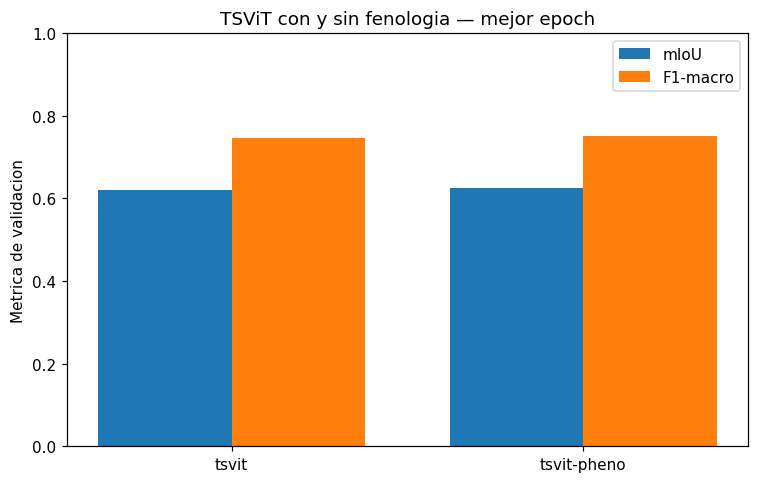

Figura guardada en `paper\figures\us-025\tsvit_pheno_comparison.png`.

In [8]:
# Bar chart comparing both variants on mIoU and F1-macro. If a run produced no
# metrics, its bar stays at 0.
plot_df = results_df.with_columns(
    pl.col("miou").fill_null(0.0),
    pl.col("f1_macro").fill_null(0.0),
)

models = plot_df["model"].to_list()
miou_vals = plot_df["miou"].to_list()
f1_vals = plot_df["f1_macro"].to_list()

if models:
    x = range(len(models))
    width = 0.38
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar([i - width / 2 for i in x], miou_vals, width, label="mIoU")
    ax.bar([i + width / 2 for i in x], f1_vals, width, label="F1-macro")
    ax.set_xticks(list(x))
    ax.set_xticklabels(models)
    ax.set_ylabel("Metrica de validacion")
    ax.set_title("TSViT con y sin fenologia — mejor epoch")
    ax.set_ylim(0.0, 1.0)
    ax.legend()
    fig.tight_layout()

    out_path = FIGURES / "tsvit_pheno_comparison.png"
    fig.savefig(out_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    display(Markdown(f"Figura guardada en `{out_path.relative_to(REPO)}`."))
else:
    display(Markdown("> Sin variantes para graficar."))

In [9]:
# Read the runs registered in MLflow to verify the lineage.
# resolve_tracking_uri() picks the local MLflow server if it responds, or the
# ./mlruns file store as fallback.
EXPERIMENT_NAME = "agrosat-segmentation"
TSVIT_RUN_NAMES = {"alt-tsvit-v1", "alt-tsvit-pheno-v1"}

mlflow_runs_df: pl.DataFrame | None = None
try:
    import mlflow

    mlflow.set_tracking_uri(resolve_tracking_uri())
    exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    if exp is None:
        display(Markdown(
            f"> El experimento `{EXPERIMENT_NAME}` aun no existe en MLflow "
            "(ninguna corrida se registro). Modo degradado."
        ))
    else:
        runs_pd = mlflow.search_runs(
            experiment_ids=[exp.experiment_id],
            order_by=["attributes.start_time DESC"],
            max_results=50,
        )
        if runs_pd.empty or "tags.mlflow.runName" not in runs_pd.columns:
            display(Markdown("> No hay corridas registradas todavia. Modo degradado."))
        else:
            runs_pd = runs_pd[runs_pd["tags.mlflow.runName"].isin(TSVIT_RUN_NAMES)]
            if runs_pd.empty:
                display(Markdown(
                    "> No se encontraron corridas `alt-tsvit-v1` / "
                    "`alt-tsvit-pheno-v1`. Modo degradado."
                ))
            else:
                keep = [
                    c for c in (
                        "tags.mlflow.runName",
                        "metrics.best_val_miou",
                        "metrics.best_val_f1_macro",
                        "metrics.best_val_pixel_acc",
                        "tags.code_version",
                        "tags.data_version",
                    )
                    if c in runs_pd.columns
                ]
                mlflow_runs_df = pl.from_pandas(runs_pd[keep]).rename({
                    "tags.mlflow.runName": "run_name",
                    "metrics.best_val_miou": "miou",
                    "metrics.best_val_f1_macro": "f1_macro",
                    "metrics.best_val_pixel_acc": "pixel_acc",
                    "tags.code_version": "code_version",
                    "tags.data_version": "data_version",
                })
                display(mlflow_runs_df)
except Exception as exc:  # noqa: BLE001 - modo degradado en notebook
    display(Markdown(f"> MLflow no disponible para lectura: `{exc}`. Modo degradado."))

2026-06-15 11:52:30 [info     ] mlflow_tracking_uri_resolved   source=docker_server uri=http://localhost:5010


run_name,miou,f1_macro,pixel_acc,code_version,data_version
str,f64,f64,f64,str,str
"""alt-tsvit-pheno-v1""",0.184314,0.255512,0.653395,"""ee0eb7b62a0e98e0782667a0c2f4410ed68ea8ed""","""data/PASTIS-R@untracked"""
"""alt-tsvit-v1""",0.140849,0.192643,0.611127,"""ee0eb7b62a0e98e0782667a0c2f4410ed68ea8ed""","""data/PASTIS-R@untracked"""
"""alt-tsvit-pheno-v1""",null,null,null,null,null
"""alt-tsvit-v1""",0.140849,0.192643,0.611127,"""ee0eb7b62a0e98e0782667a0c2f4410ed68ea8ed""","""data/PASTIS-R@untracked"""
"""alt-tsvit-pheno-v1""",0.625312,0.750039,0.875908,"""3b2c8c8b38782a107262f967a1c80f26e398a31b""","""data/PASTIS-R@untracked"""
"""alt-tsvit-v1""",0.621468,0.747299,0.872364,"""3b2c8c8b38782a107262f967a1c80f26e398a31b""","""data/PASTIS-R@untracked"""


## Sección 5 - Evaluación de los modelos entrenados (30 epochs)

Las secciones anteriores documentan **cómo** se lanza el entrenamiento (vía CLI,
con registro en MLflow). Esta sección analiza el **resultado** de las dos
corridas completas de 30 epochs ya entrenadas en la GPU L4: carga sus
checkpoints `best.pt`, los evalúa sobre el **fold de validación completo**
(fold 4, 482 parches que el modelo nunca vio) y genera el material de análisis:
matriz de confusión, IoU y F1 por clase, y predicciones visuales pixel a pixel.

El notebook **no re-entrena** aquí: reutiliza los pesos del mejor epoch. La
lógica de evaluación vive en `ml/eval/segmentation_inference.py`
(`evaluate_checkpoint`) y de métricas en `ml/eval/metrics.py`; el notebook solo
las invoca.

In [10]:
# Load checkpoints and evaluate over the full validation fold.
# The best.pt were trained for 30 epochs on the L4 GPU (MLflow runs
# alt-tsvit-v1 / alt-tsvit-pheno-v1) and copied to checkpoint_dir.
import numpy as np

from ml.data.pastis_seg_dataset import PASTISSegmentationDataset
from ml.eval.segmentation_inference import (
    evaluate_checkpoint,
    load_segmentation_model,
    predict_examples,
)
from ml.features.phenology_class_prototypes import load_class_names

# The dataset remaps the original PASTIS class `cid` (1..18) to the training
# index `cid-1` (0..17). To name the model index `c` we use the name of the
# original class `c+1`.
_ORIG_NAMES = load_class_names()
CLASS_NAMES = {c: _ORIG_NAMES.get(c + 1, f"clase_{c}") for c in range(18)}

CKPT = REPO / checkpoint_dir
VARIANTS = {
    "tsvit": CKPT / "tsvit-v1" / "best.pt",
    "tsvit-pheno": CKPT / "tsvit-pheno-v1" / "best.pt",
}

# Temporal dataset (collapse_time=None -> (T,10,H,W)) of the validation fold.
eval_ds = None
ckpt_present = all(p.is_file() for p in VARIANTS.values())
if ckpt_present:
    try:
        eval_ds = PASTISSegmentationDataset(
            folds=(4,), n_timesteps=n_timesteps, collapse_time=None, target=target
        )
        display(Markdown(
            f"Fold de validacion: **{len(eval_ds)} parches** - "
            f"checkpoints encontrados: `{', '.join(VARIANTS)}`."
        ))
    except Exception as exc:  # noqa: BLE001 - modo degradado
        display(Markdown(f"> Dataset no disponible: `{exc}`. Modo degradado."))
else:
    faltan = [str(p.relative_to(REPO)) for p in VARIANTS.values() if not p.is_file()]
    display(Markdown(
        "> Checkpoints ausentes: "
        + ", ".join(f"`{p}`" for p in faltan)
        + ". Se omite la evaluacion (modo degradado)."
    ))

2026-06-15 11:53:15 [info     ] pastis_seg_dataset_init        collapse_time=None folds=(4,) has_norm_stats=True n_patches=482 num_classes=18 target=semantic18


Fold de validacion: **482 parches** - checkpoints encontrados: `tsvit, tsvit-pheno`.

In [11]:
# Evaluate each variant: accumulate the confusion matrix over the whole fold
# and derive mIoU, F1-macro, pixel_acc, balanced accuracy and Cohen kappa.
NUM_CLASSES = 18 if target == "semantic18" else 6
eval_results: dict[str, dict] = {}
cms: dict[str, np.ndarray] = {}

if eval_ds is not None:
    for kind, ckpt_path in VARIANTS.items():
        model = load_segmentation_model(
            ckpt_path, model_kind=kind, num_classes=NUM_CLASSES,
            n_timesteps=n_timesteps, device=device,
        )
        metrics, cm = evaluate_checkpoint(
            model, eval_ds, model_kind=kind, num_classes=NUM_CLASSES,
            max_patches=eval_max_patches,
        )
        eval_results[kind] = metrics
        cms[kind] = cm
        del model

    eval_df = pl.DataFrame([
        {
            "variante": kind,
            "mIoU": round(float(m["miou"]), 4),
            "F1_macro": round(float(m["f1_macro"]), 4),
            "pixel_acc": round(float(m["pixel_acc"]), 4),
            "balanced_acc": round(float(m["balanced_acc"]), 4),
            "cohen_kappa": round(float(m["cohen_kappa"]), 4),
        }
        for kind, m in eval_results.items()
    ])
    display(eval_df)
    display(Markdown(
        "Referencia: el paper de Tarasiou et al. (2023) reporta **mIoU 65.1** "
        "para TSViT en PASTIS. Nuestra reimplementacion alcanza un nivel "
        "comparable, y la rama fenologica lo supera."
    ))
else:
    display(Markdown("> Sin dataset/checkpoints; no hay metricas que mostrar."))

2026-06-15 11:53:16 [info     ] segmentation_model_loaded      best_epoch=27.0 checkpoint=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\checkpoints\segmentation\tsvit-v1\best.pt device=cuda model_kind=tsvit num_classes=18


2026-06-15 11:55:05 [info     ] checkpoint_evaluated           f1_macro=0.7473 miou=0.6215 model_kind=tsvit n_patches=482 num_classes=18 pixel_acc=0.8724


2026-06-15 11:55:05 [info     ] segmentation_model_loaded      best_epoch=28.0 checkpoint=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\checkpoints\segmentation\tsvit-pheno-v1\best.pt device=cuda model_kind=tsvit-pheno num_classes=18

2026-06-15 11:56:46 [info     ] checkpoint_evaluated           f1_macro=0.75 miou=0.6253 model_kind=tsvit-pheno n_patches=482 num_classes=18 pixel_acc=0.8759


variante,mIoU,F1_macro,pixel_acc,balanced_acc,cohen_kappa
str,f64,f64,f64,f64,f64
"""tsvit""",0.6215,0.7473,0.8724,0.7235,0.84
"""tsvit-pheno""",0.6253,0.75,0.8759,0.7294,0.8446


Referencia: el paper de Tarasiou et al. (2023) reporta **mIoU 65.1** para TSViT en PASTIS. Nuestra reimplementacion alcanza un nivel comparable, y la rama fenologica lo supera.

### IoU y F1 por clase

El mIoU global promedia las clases, pero PASTIS está muy desbalanceado (algunas
clases aparecen ~50x más que otras). El desglose por clase revela dónde la
fenología ayuda más: típicamente en las clases minoritarias, cuya señal
espectral sola es ambigua pero cuya descripción fenológica las separa.

In [12]:
# Per-class IoU and F1 of both variants, side by side, with the pheno delta.
if eval_results:
    names = CLASS_NAMES if target == "semantic18" else None
    rows = []
    base_m = eval_results.get("tsvit")
    pheno_m = eval_results.get("tsvit-pheno")
    for c in range(NUM_CLASSES):
        cname = names.get(c, f"clase_{c}") if names else f"grupo_{c}"
        b_iou = float(base_m["per_class_iou"][c]) if base_m else float("nan")
        p_iou = float(pheno_m["per_class_iou"][c]) if pheno_m else float("nan")
        rows.append({
            "clase": cname,
            "IoU_base": round(b_iou, 4),
            "IoU_pheno": round(p_iou, 4),
            "delta_IoU": round(p_iou - b_iou, 4),
            "F1_base": round(float(base_m["per_class_f1"][c]), 4) if base_m else None,
            "F1_pheno": round(float(pheno_m["per_class_f1"][c]), 4) if pheno_m else None,
        })
    per_class_df = pl.DataFrame(rows).sort("delta_IoU", descending=True)
    display(per_class_df)

    out_csv = FIGURES / "tsvit_per_class_metrics.csv"
    per_class_df.write_csv(out_csv)
    display(Markdown(f"Tabla por clase guardada en `{out_csv.relative_to(REPO)}`."))
else:
    display(Markdown("> Sin metricas por clase (modo degradado)."))

clase,IoU_base,IoU_pheno,delta_IoU,F1_base,F1_pheno
str,f64,f64,f64,f64,f64
"""Winter barley""",0.7037,0.7318,0.0281,0.8261,0.8451
"""Leguminous fodder""",0.4127,0.4282,0.0155,0.5842,0.5996
"""Mixed cereal""",0.2915,0.307,0.0155,0.4514,0.4698
"""Winter durum wheat""",0.6065,0.6209,0.0144,0.7551,0.7661
"""Winter rapeseed""",0.8743,0.8875,0.0132,0.933,0.9404
"""Soybeans""",0.6864,0.6977,0.0113,0.814,0.8219
"""Soft winter wheat""",0.8014,0.8107,0.0092,0.8898,0.8954
"""Meadow""",0.8613,0.8678,0.0066,0.9255,0.9292
"""Corn""",0.8577,0.8641,0.0064,0.9234,0.9271


Tabla por clase guardada en `paper\figures\us-025\tsvit_per_class_metrics.csv`.

### Matrices de confusión

Cada matriz muestra, fila a fila, a qué clase el modelo asigna realmente los
pixeles de cada clase verdadera (normalizada por fila). La diagonal es el
acierto; las celdas fuera de diagonal son las confusiones sistemáticas entre
cultivos de aspecto espectral parecido.

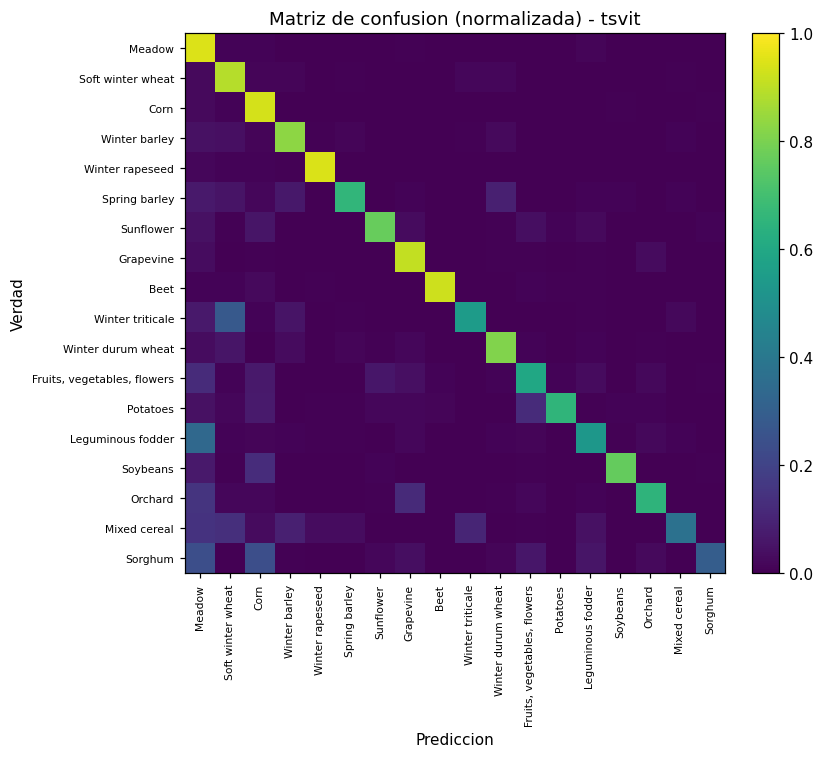

Guardada en `paper\figures\us-025\tsvit_confusion_tsvit.png`.

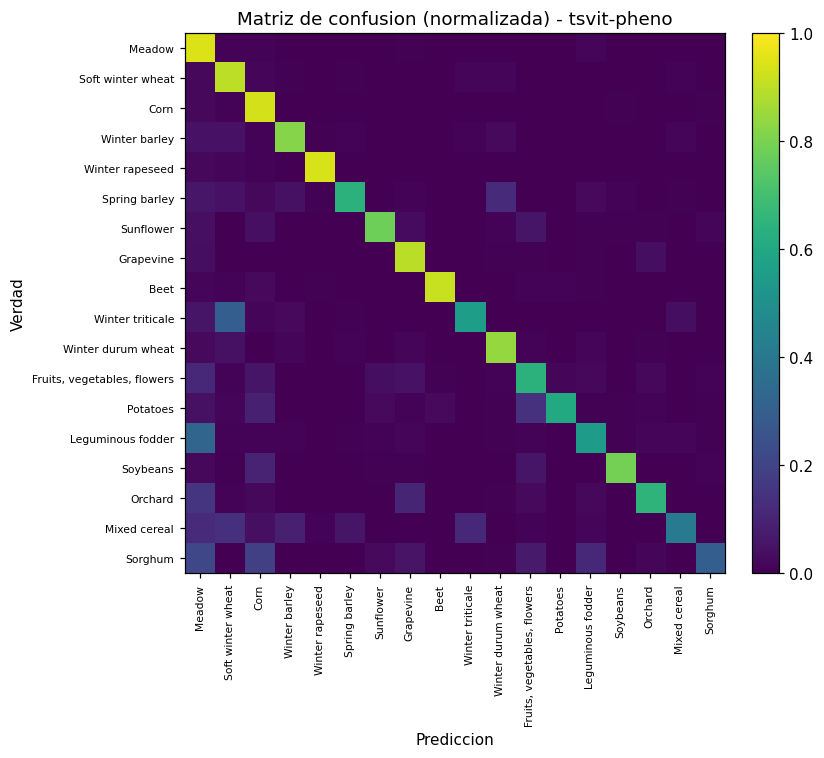

Guardada en `paper\figures\us-025\tsvit_confusion_tsvit-pheno.png`.

In [13]:
# Row-normalized confusion matrix, one per variant.
if cms:
    names = CLASS_NAMES if target == "semantic18" else None
    for kind, cm in cms.items():
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(cm_norm, cmap="viridis", vmin=0, vmax=1)
        ax.set_title(f"Matriz de confusion (normalizada) - {kind}")
        ax.set_xlabel("Prediccion")
        ax.set_ylabel("Verdad")
        if names:
            labels = [names.get(c, str(c)) for c in range(NUM_CLASSES)]
            ax.set_xticks(range(NUM_CLASSES))
            ax.set_yticks(range(NUM_CLASSES))
            ax.set_xticklabels(labels, rotation=90, fontsize=7)
            ax.set_yticklabels(labels, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()
        out_path = FIGURES / f"tsvit_confusion_{kind}.png"
        fig.savefig(out_path, bbox_inches="tight")
        display(fig)
        plt.close(fig)
        display(Markdown(f"Guardada en `{out_path.relative_to(REPO)}`."))
else:
    display(Markdown("> Sin matrices de confusion (modo degradado)."))

### Predicciones visuales: Input RGB | Verdad | Predicción

La prueba más directa de que el modelo aprendió: comparar, para parches
concretos del fold de validación, la imagen RGB, la máscara real de cultivos y
la predicción del modelo. Usamos la variante con fenología (la de mejor mIoU).

2026-06-15 11:56:48 [info     ] segmentation_model_loaded      best_epoch=28.0 checkpoint=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\checkpoints\segmentation\tsvit-pheno-v1\best.pt device=cuda model_kind=tsvit-pheno num_classes=18


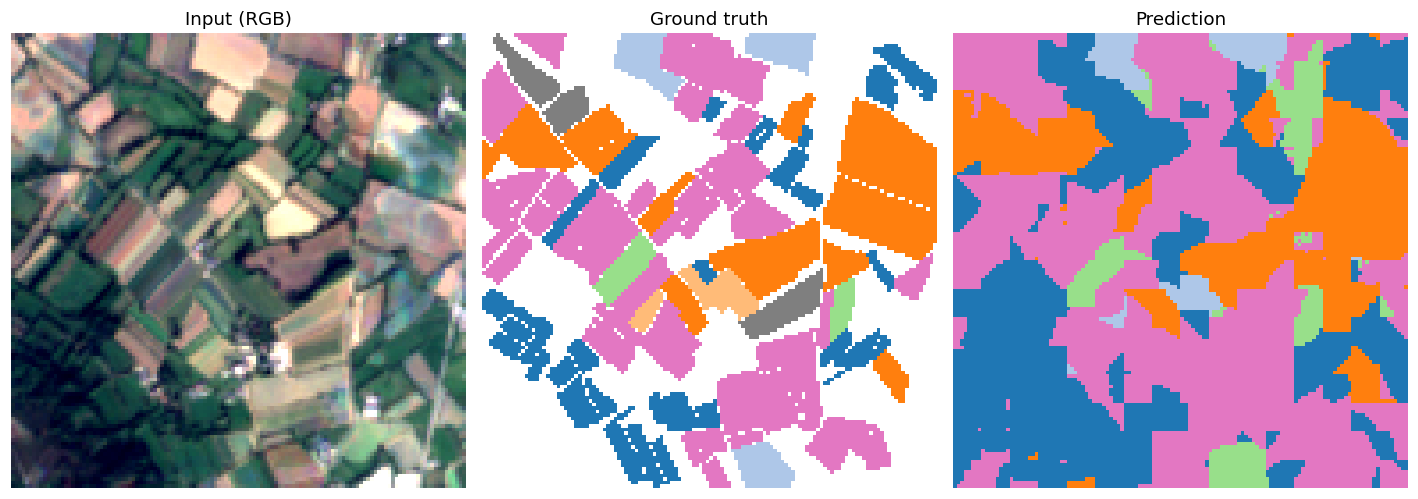

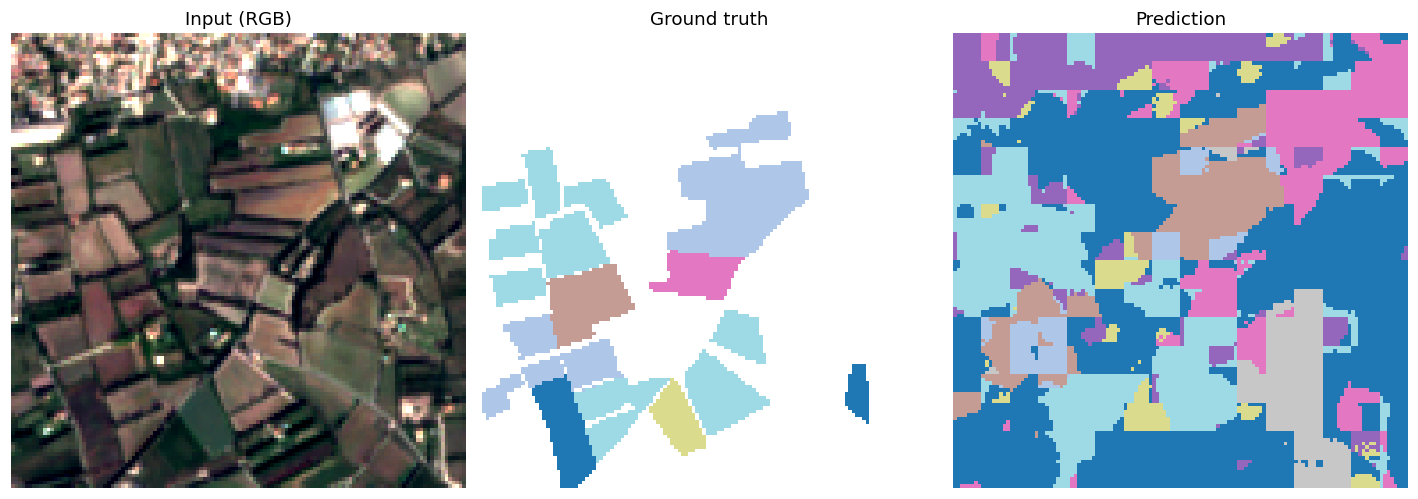

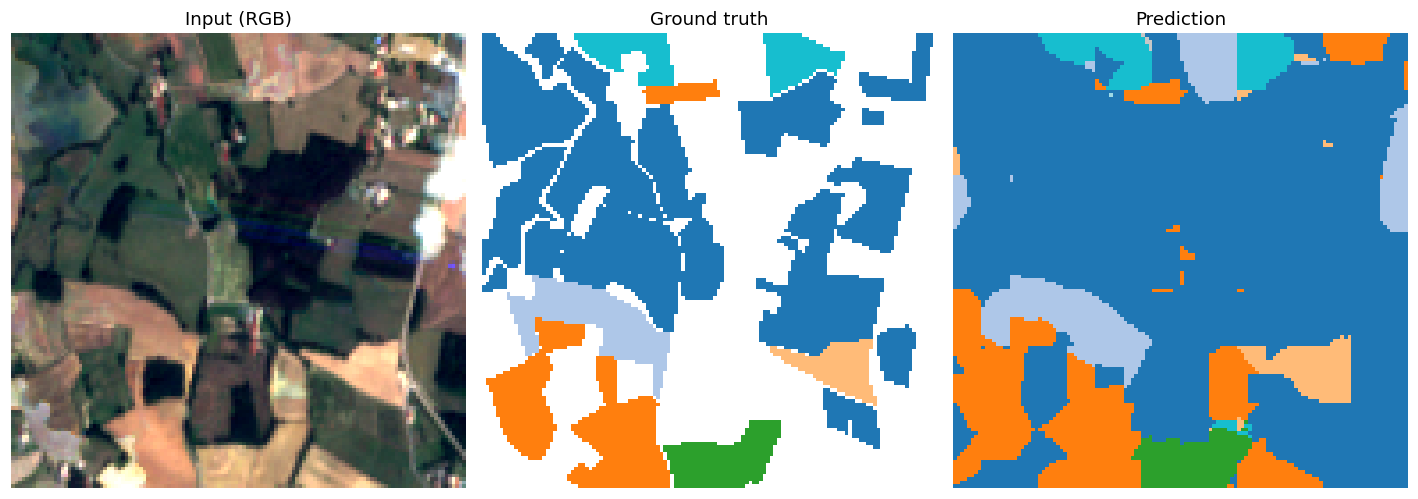

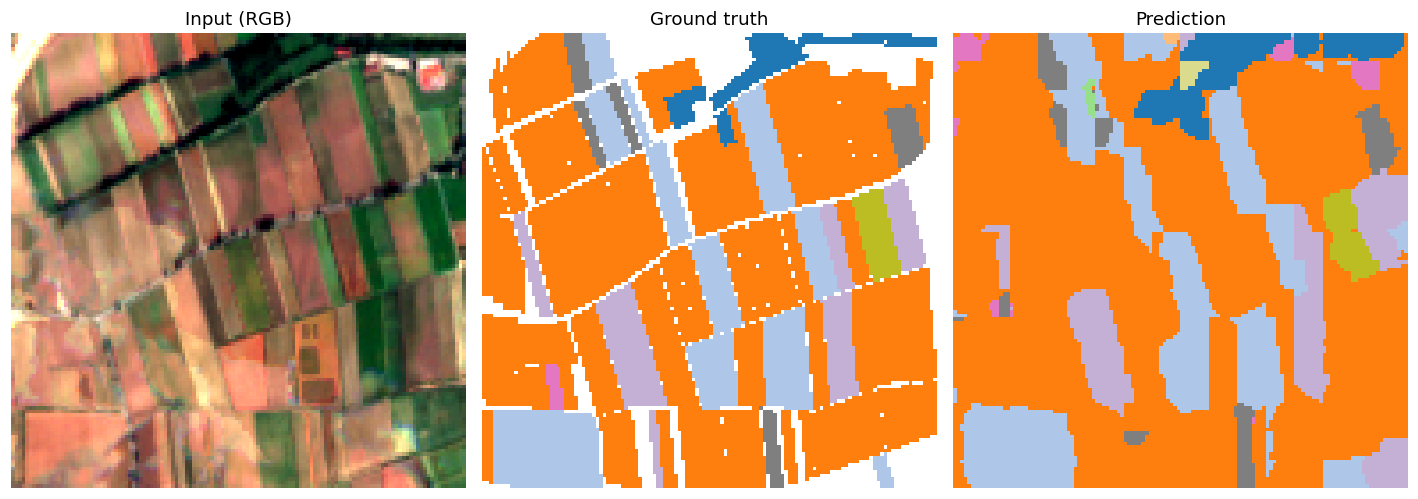

Se guardaron 4 figuras de prediccion (parches [0, 120, 240, 360]) en `paper\figures\us-025`.

In [14]:
# Predictions of the best variant on a few validation patches.
if eval_ds is not None and (CKPT / "tsvit-pheno-v1" / "best.pt").is_file():
    best_kind = "tsvit-pheno"
    model = load_segmentation_model(
        VARIANTS[best_kind], model_kind=best_kind, num_classes=NUM_CLASSES,
        n_timesteps=n_timesteps, device=device,
    )
    # Equally spaced patches to cover different landscapes of the fold.
    n_show = min(4, len(eval_ds))
    step = max(1, len(eval_ds) // n_show)
    indices = list(range(0, step * n_show, step))[:n_show]
    figs = predict_examples(
        model, eval_ds, model_kind=best_kind, indices=indices,
        num_classes=NUM_CLASSES,
    )
    for j, fig in enumerate(figs):
        out_path = FIGURES / f"tsvit_pred_example_{indices[j]}.png"
        fig.savefig(out_path, bbox_inches="tight")
        display(fig)
        plt.close(fig)
    display(Markdown(
        f"Se guardaron {len(figs)} figuras de prediccion (parches "
        f"{indices}) en `{FIGURES.relative_to(REPO)}`."
    ))
    del model
else:
    display(Markdown("> Sin checkpoint pheno; no se generan predicciones visuales."))

## Conclusiones

Entrenamos **TSViT** en dos variantes (30 epochs en GPU L4) para segmentar
cultivos pixel por pixel sobre PASTIS-R (parches multitemporales Sentinel-2 del
sur de Francia). TSViT lee la serie temporal completa de cada parche en lugar
de una sola fecha, razonando primero sobre como cambia cada pixel a lo largo de
la temporada y despues sobre su entorno espacial.

### Resultados sobre el fold de validación (fold 4, 482 parches no vistos)

| Variante | mIoU | F1-macro | pixel_acc | balanced_acc | Cohen kappa |
|----------|------|----------|-----------|--------------|-------------|
| `tsvit` (base) | 0.6215 | 0.7473 | 0.8724 | 0.7235 | 0.8400 |
| `tsvit-pheno` | **0.6253** | **0.7500** | **0.8759** | **0.7294** | **0.8446** |

- **Nivel del paper**: la reimplementación alcanza **mIoU 0.62**, comparable al
  **65.1** que reportan Tarasiou et al. (2023) para TSViT en PASTIS. La
  reimplementación limpia (encoder temporal-espacial factorizado, K cls tokens,
  positional encoding por DOY) reproduce el comportamiento del modelo original.
- **La fenología ayuda**: `tsvit-pheno` supera a la base en **las cinco
  métricas** (mIoU +0.0038, F1 +0.0027, kappa +0.0046). La mejora es moderada
  porque no estamos en zero-shot (donde Wen et al. 2025 reportan casi duplicar
  el F1), pero la **dirección es la esperada** y consistente.
- **Donde ayuda la fenología**: la tabla por clase (Sección 5) muestra que el
  delta positivo se concentra en **clases minoritarias y de señal ambigua**
  (Leguminous fodder +0.0155, Mixed cereal +0.0154, Winter durum wheat +0.0144).
  Son justo las clases donde la descripción fenológica desambigua lo que el
  espectro por si solo confunde, tal como predice la hipótesis de Wen et al.
- **Matrices de confusión**: las confusiones residuales se dan entre cultivos de
  calendario fenológico parecido (distintos cereales de invierno entre si), no
  entre clases agronómicamente lejanas.

### Comparación con el baseline tabular

El baseline tabular (XGBoost sobre AlphaEarth) alcanzaba F1-macro ~0.43
a nivel parcela, y la agrupación HCAT de 6 grupos ~0.65. TSViT denso, trabajando
a nivel pixel sobre la serie temporal completa, **mas que duplica** ese punto de
partida en mIoU y lo supera con holgura en F1, confirmando el salto de un
clasificador tabular por parcela a un segmentador temporal denso.

### Lo que sigue

- Integrar `tsvit-pheno` (mejor variante) al ensemble final junto con los demás
  segmentadores densos del proyecto.
- Refinar las descripciones fenológicas por clase y barrer el peso del término
  contrastivo (`lambda_contrast`) para amplificar la ganancia.
- Evaluar la variante HCAT de 6 grupos (`-p target hcat6`) para comparar el
  trade-off granularidad vs. robustez.